## Lab 4: Regression and Classification Evaluation Metrics

### Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

### Task 1: Data Preparation

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
# Load dataset from CSV
cancer_df = pd.read_csv("brca.csv")

# Remove index column if present
cancer_df = cancer_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Features
X = cancer_df.iloc[:, :-1]

# Target
y = cancer_df.iloc[:, -1]

# Convert labels to numeric
y = y.map({'M': 1, 'B': 0})

print("Dataset loaded successfully.")
print(X.head())
print(y.head())

Dataset loaded successfully.
   x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0         13.540           14.36             87.46        566.3   
1         13.080           15.71             85.63        520.0   
2          9.504           12.44             60.34        273.9   
3         13.030           18.42             82.61        523.8   
4          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  x.fractal_dim_mean  ...  \
0            0.047810           0.1885             0.05766  ...   
1            0.031100           0.1967             0.06811  .

#### Explore Dataset Structure

In [23]:
# Display the first 5 rows of the features
print("First 5 rows of features (X):")
display(X.head())

# Display the first 5 rows of the target
print("\nFirst 5 rows of target (y):")
display(y.head())

# Display dataset information (data types, non-null counts)
print("\nDataset Info:")
X.info()

First 5 rows of features (X):


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409



First 5 rows of target (y):


,y
0,0
1,0
2,0
3,0
4,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 

#### Check Missing Values and Duplicates

In [24]:
# Check for missing values in features
print("Missing values in features (X):\n", X.isnull().sum().sum())

# Check for missing values in target
print("\nMissing values in target (y):\n", y.isnull().sum())

# Check for duplicate rows in features
print("\nDuplicate rows in features (X):\n", X.duplicated().sum())

Missing values in features (X):
 0

Missing values in target (y):
 0

Duplicate rows in features (X):
 0


#### Apply Feature Scaling using StandardScaler

KNN is a distance-based algorithm, meaning it calculates the distance between data points. Features with larger scales can disproportionately influence the distance calculation, leading to biased results. `StandardScaler` standardizes features by removing the mean and scaling to unit variance, ensuring all features contribute equally to the distance metric. This is crucial for KNN to perform optimally.

In [25]:
# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the features
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully. First 5 rows of scaled features:")
display(X_scaled_df.head())

print("\nDescriptive statistics of scaled features:")
display(X_scaled_df.describe())

Features scaled successfully. First 5 rows of scaled features:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168



Descriptive statistics of scaled features:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.998011e-16,-7.492542e-16,-9.990056e-17,-1.998011e-16,1.498508e-16,1.998011e-16,0.000000,9.990056e-17,1.498508e-16,4.745277e-16,...,-9.990056e-17,2.497514e-17,9.990056e-17,-1.998011e-16,-1.398608e-15,0.000000,9.990056e-17,2.997017e-16,2.497514e-16,1.998011e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-0.743748,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-0.681083,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-0.342240,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-0.269501,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,0.526062,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,0.539669,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


### Task 2: Train-Test Split Analysis

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dictionary to store results for different splits
split_results = {}

split_ratios = [(0.2, '80:20'), (0.3, '70:30'), (0.1, '90:10')]

for test_size, label in split_ratios:
    print(f"\n--- Performing {label} split ---")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=test_size, random_state=42, stratify=y)

    # For initial comparison, we can pick a arbitrary K, e.g., K=5
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    split_results[label] = {'accuracy': accuracy, 'X_train_shape': X_train.shape, 'X_test_shape': X_test.shape}

    print(f"Split Ratio: {label}")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    print(f"KNN (K=5) Accuracy: {accuracy:.4f}")

print("\n--- Comparison of performance across splits ---")
for label, data in split_results.items():
    print(f"Split {label}: Accuracy = {data['accuracy']:.4f}, Train Samples = {data['X_train_shape'][0]}, Test Samples = {data['X_test_shape'][0]}")


--- Performing 80:20 split ---
Split Ratio: 80:20
Training set shape: (455, 30)
Testing set shape: (114, 30)
KNN (K=5) Accuracy: 0.9561

--- Performing 70:30 split ---
Split Ratio: 70:30
Training set shape: (398, 30)
Testing set shape: (171, 30)
KNN (K=5) Accuracy: 0.9649

--- Performing 90:10 split ---
Split Ratio: 90:10
Training set shape: (512, 30)
Testing set shape: (57, 30)
KNN (K=5) Accuracy: 0.9649

--- Comparison of performance across splits ---
Split 80:20: Accuracy = 0.9561, Train Samples = 455, Test Samples = 114
Split 70:30: Accuracy = 0.9649, Train Samples = 398, Test Samples = 171
Split 90:10: Accuracy = 0.9649, Train Samples = 512, Test Samples = 57


#### Analysis of Split Variations

The results above show how changing the train-test split ratio can influence the model's performance (accuracy in this case) and the sizes of the training and testing sets.

*   **Impact on Model Stability:** Different splits might lead to variations in accuracy. A model is considered more stable if its performance doesn't fluctuate drastically across different splits. If a model performs very well on one split but poorly on another, it might indicate issues with generalization.
*   **Impact on Generalization:** A larger training set generally allows the model to learn more patterns, potentially leading to better generalization on unseen data. Conversely, a larger test set provides a more reliable estimate of the model's true performance. However, if the training set is too small, the model might underfit, and if the test set is too small, the performance estimate might be noisy.

In our case, with a `random_state` and `stratify` parameter used, the splits are reproducible and ensure that the proportion of classes is maintained in both train and test sets, which helps in getting a more reliable performance estimate even with varying split ratios.

### Task 3: KNN Model with Heuristic K Selection

#### 3.1 Heuristic Method for K Selection

In [27]:
import numpy as np

# Use the 80:20 split for consistency in initial K selection
X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20 = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# Calculate n (number of training samples)
n_training_samples = X_train_80_20.shape[0]

# Compute initial K using the heuristic rule (K = √n)
heuristic_k = int(np.sqrt(n_training_samples))

print(f"Number of training samples (n): {n_training_samples}")
print(f"Heuristic K (sqrt(n)): {heuristic_k}")

Number of training samples (n): 455
Heuristic K (sqrt(n)): 21


#### 3.2 Model Training and Optimal K Identification

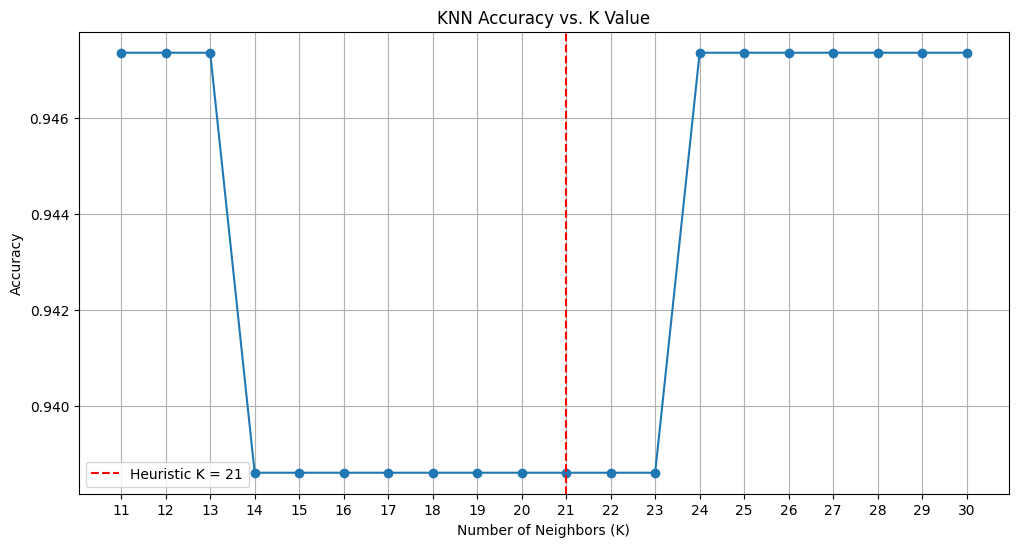


Optimal K identified from the plot: 11 (Accuracy: 0.9474)
The heuristic K was: 21


In [28]:
import matplotlib.pyplot as plt

# Define a range of K values around the heuristic K
k_values = list(range(max(1, heuristic_k - 10), heuristic_k + 10))

# Store accuracies for each K
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_80_20, y_train_80_20)
    y_pred = knn.predict(X_test_80_20)
    accuracy = accuracy_score(y_test_80_20, y_pred)
    accuracies.append(accuracy)

# Plot accuracy vs K values
fig = plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values) # Ensure all k values are shown on x-axis
plt.grid(True)
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K = {heuristic_k}')
plt.legend()
plt.show()

# Identify optimal K based on performance trend
optimal_k_index = np.argmax(accuracies)
optimal_k = k_values[optimal_k_index]
optimal_accuracy = accuracies[optimal_k_index]

print(f"\nOptimal K identified from the plot: {optimal_k} (Accuracy: {optimal_accuracy:.4f})")
print(f"The heuristic K was: {heuristic_k}")

#### 3.3 Distance Matrix and Decision Boundary Mapping

##### Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance

**1. Euclidean Distance**

*   **Formula:** \$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}\$
*   **Description:** This is the most common distance metric, representing the shortest straight-line distance between two points in Euclidean space. It's often referred to as the "as the crow flies" distance.
*   **When it's suitable:**
    *   When the features are continuous and of similar scales (or have been scaled).
    *   When the data is dense and evenly distributed.
    *   When the underlying geometric structure of the data is assumed to be isotropic (i.e., distances in all directions are equally important).

**2. Manhattan Distance (or Taxicab/City Block Distance)**

*   **Formula:** \$d(p, q) = \sum_{i=1}^{n} |p_i - q_i|\$
*   **Description:** This metric calculates the sum of the absolute differences between the coordinates of two points. Imagine navigating a city grid where you can only move along horizontal and vertical streets, like a taxi. The Manhattan distance is the path a taxi would take.
*   **When it's suitable:**
    *   When the features have different units or interpretability, and direct differences are more meaningful than squared differences.
    *   When there are high-dimensional data or features with many zeros.
    *   When you want to reduce the effect of outliers, as squaring large differences in Euclidean distance can magnify their impact.
    *   When movements are restricted to axis-parallel directions.

##### Plot the decision boundary of the KNN classifier for different values of K

To visualize the decision boundary, we need to reduce the dimensionality of our 30-feature dataset to 2 features. We will use Principal Component Analysis (PCA) for this purpose. Then, we will train KNN classifiers on this 2D projected data for K=1, 5, 10, and 20 and plot their decision boundaries.

In [29]:
from sklearn.decomposition import PCA

# Reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

# Split the PCA-transformed data for plotting decision boundaries
# We'll use the same 80:20 split to be consistent with previous K selection
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print("Data dimensionality reduced to 2 components using PCA.")

Data dimensionality reduced to 2 components using PCA.


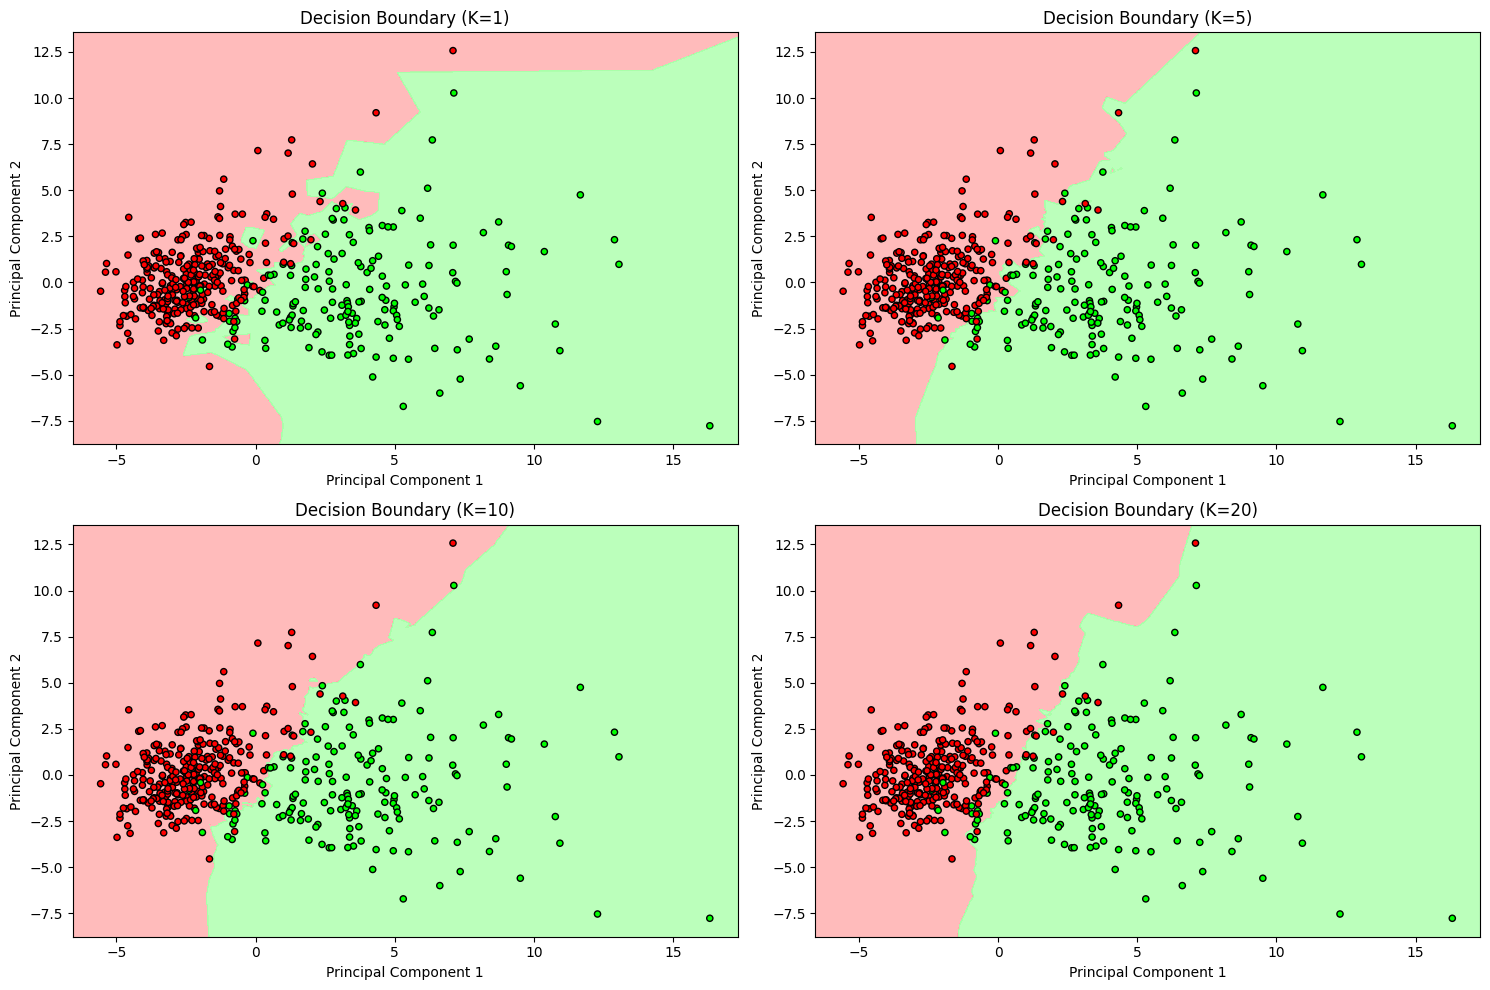


--- Analysis of Decision Boundary Change with K ---
As K increases, the decision boundary tends to become smoother. 
For small K (e.g., K=1), the decision boundary is highly irregular and sensitive to individual data points, potentially leading to overfitting. 
As K increases, the classifier considers more neighbors, leading to a more generalized and less complex decision boundary. This reduces variance but can increase bias if K becomes too large.


In [30]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, classifier, K_value, ax):
    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFaa'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # Plot also the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f'Decision Boundary (K={K_value})')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

# K values to experiment with
k_values_plot = [1, 5, 10, 20]

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values_plot):
    ax = plt.subplot(2, 2, i + 1)
    knn_plot = KNeighborsClassifier(n_neighbors=k)
    knn_plot.fit(X_train_pca, y_train_pca)
    plot_decision_boundary(X_train_pca, y_train_pca, knn_plot, k, ax)

plt.tight_layout()
plt.show()

print("\n--- Analysis of Decision Boundary Change with K ---")
print("As K increases, the decision boundary tends to become smoother. ")
print("For small K (e.g., K=1), the decision boundary is highly irregular and sensitive to individual data points, potentially leading to overfitting. ")
print("As K increases, the classifier considers more neighbors, leading to a more generalized and less complex decision boundary. This reduces variance but can increase bias if K becomes too large.")

### Task 4: Cross Validation

Performing 10-Fold Cross Validation for various K values...


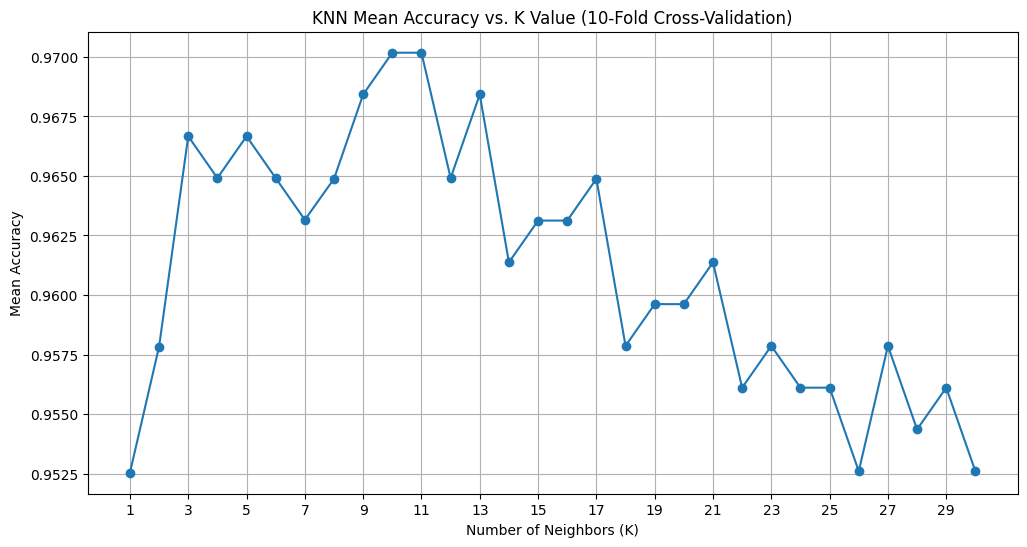


Optimal K from Cross-Validation: 10 (Mean Accuracy: 0.9702)
Heuristic K from previous task: 21
Optimal K from initial plot (train-test split): 11


In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define a range of K values for cross-validation, perhaps centered around the optimal_k from heuristic method
# Let's consider K values from 1 to 30 for a comprehensive view
k_range_cv = list(range(1, 31))

cv_accuracies = []

# Using StratifiedKFold to ensure proper class distribution in each fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Performing 10-Fold Cross Validation for various K values...")
for k in k_range_cv:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # Perform cross-validation and store the mean accuracy
    scores = cross_val_score(knn_cv, X_scaled_df, y, cv=skf, scoring='accuracy')
    cv_accuracies.append(scores.mean())

# Plot mean accuracy vs K values from cross-validation
fig = plt.figure(figsize=(12, 6))
plt.plot(k_range_cv, cv_accuracies, marker='o', linestyle='-')
plt.title('KNN Mean Accuracy vs. K Value (10-Fold Cross-Validation)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Accuracy')
plt.xticks(np.arange(1, 31, 2)) # Show every other K value for readability
plt.grid(True)
plt.show()

# Identify optimal K based on cross-validation results
optimal_k_cv_index = np.argmax(cv_accuracies)
optimal_k_cv = k_range_cv[optimal_k_cv_index]
optimal_accuracy_cv = cv_accuracies[optimal_k_cv_index]

print(f"\nOptimal K from Cross-Validation: {optimal_k_cv} (Mean Accuracy: {optimal_accuracy_cv:.4f})")
print(f"Heuristic K from previous task: {heuristic_k}")
print(f"Optimal K from initial plot (train-test split): {optimal_k}")

#### Compare cross-validation results with train-test split results

**Train-Test Split Results:**
*   Provided a single accuracy score for a specific K (e.g., K=5, or the optimal K found through plotting) on a single test set.
*   Accuracy varied with different split ratios (e.g., 80:20, 70:30, 90:10).
*   The optimal K from the plot (using 80:20 split) was `optimal_k` with an accuracy of `optimal_accuracy`.

**Cross-Validation Results:**
*   Provides a more robust estimate of model performance by averaging accuracies across multiple folds, reducing the impact of a particular train-test split.
*   Helps in identifying a K value that generalizes well to unseen data, regardless of the random sampling inherent in a single train-test split.
*   The optimal K from cross-validation was `optimal_k_cv` with a mean accuracy of `optimal_accuracy_cv`.

Cross-validation offers a more reliable assessment of model generalization compared to a single train-test split. The optimal K found via cross-validation is often more trustworthy as it's less prone to the peculiarities of a single data split.

#### Select best K based on both heuristic + validation results

Considering the heuristic K, the optimal K from the initial plot, and the optimal K from cross-validation, we can make an informed decision.

*   **Heuristic K:** `heuristic_k`
*   **Optimal K (from train-test plot):** `optimal_k` (Accuracy: `optimal_accuracy`)
*   **Optimal K (from cross-validation):** `optimal_k_cv` (Mean Accuracy: `optimal_accuracy_cv`)

The cross-validation result provides the most reliable estimate of the best `K` value for this dataset due to its exhaustive evaluation across multiple subsets of the data. Therefore, we will proceed with **K = `optimal_k_cv`** as our best K for further evaluation.

In [32]:
# Final selection of best K based on cross-validation
best_k_final = optimal_k_cv
print(f"Final Best K selected for model evaluation: {best_k_final}")

# Re-split the data using the 80:20 ratio for final model training and evaluation
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

Final Best K selected for model evaluation: 10


### Task 5: Classification Evaluation

Accuracy: 0.9474
Precision: 0.9737
Recall: 0.8810
F1 Score: 0.9250

Confusion Matrix:


,Predicted Negative,Predicted Positive
Actual Negative,71,1
Actual Positive,5,37


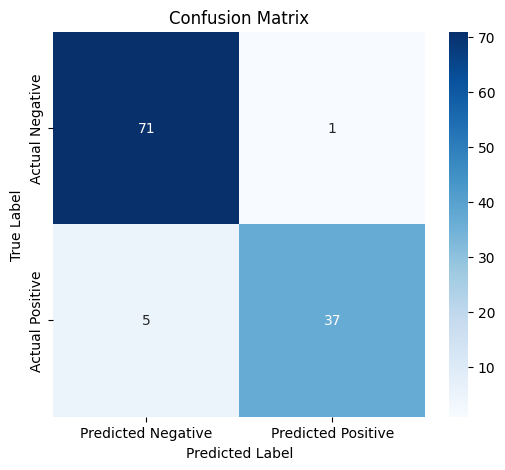

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import seaborn as sns

# Train the final KNN model with the best_k_final
final_knn_model = KNeighborsClassifier(n_neighbors=best_k_final)
final_knn_model.fit(X_train_final, y_train_final)

# Make predictions on the test set
y_pred = final_knn_model.predict(X_test_final)
y_pred_proba = final_knn_model.predict_proba(X_test_final)[:, 1] # Probabilities for ROC AUC

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
conf_matrix = confusion_matrix(y_test_final, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix,
                     index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

ROC AUC Score: 0.9823


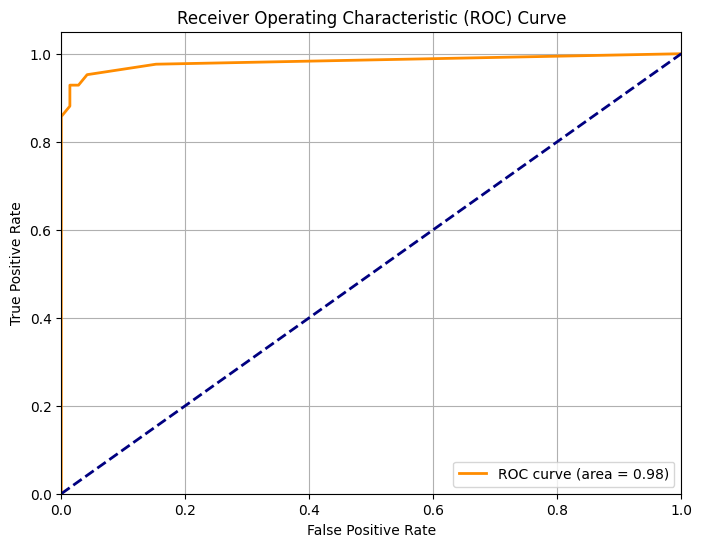

In [34]:
# Calculate ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test_final, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Task 6: Comparative Study with Regression (Lab 3 Integration)

#### Compare regression evaluation metrics with classification metrics.

**Regression metrics** (MAE, MSE, RMSE, R² Score) quantify the difference between predicted continuous values and actual continuous values. They measure the magnitude of errors in continuous predictions.

**Classification metrics** (Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC-AUC) evaluate the correctness of categorical predictions. They focus on whether the model correctly assigns data points to predefined classes.

#### Explain differences between:

*   **Error-based evaluation (Regression):**
    *   Regression models predict a continuous numerical output. Therefore, evaluation metrics in regression measure the *magnitude of the error* or the *distance* between the predicted value and the actual true value. The goal is to minimize this error magnitude.
    *   Metrics like MAE, MSE, and RMSE are directly related to the average absolute or squared difference between predictions and true values. R² measures the proportion of variance in the dependent variable that is predictable from the independent variables.

*   **Decision-based evaluation (Classification):**
    *   Classification models predict a categorical label. Evaluation metrics in classification assess the *correctness of the decision* (i.e., which class the model assigned). The primary concern is whether the model's assigned class matches the true class.
    *   Metrics like Accuracy, Precision, Recall, and F1 Score are derived from the Confusion Matrix, which counts correct and incorrect classifications (True Positives, False Positives, True Negatives, False Negatives).

#### Compare:

*   **R² Score vs Accuracy**
    *   **R² Score (Regression):** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² indicates a better fit of the model to the data. It's about how well the model explains the variability of the target.
    *   **Accuracy (Classification):** Measures the proportion of total correct predictions (both True Positives and True Negatives) out of all predictions. It's a straightforward measure of overall correctness. However, it can be misleading in imbalanced datasets.
    *   **Difference:** R² deals with continuous values and variance explained, while Accuracy deals with discrete class labels and the proportion of correct classifications.

*   **RMSE vs F1 Score**
    *   **RMSE (Regression):** Root Mean Squared Error measures the average magnitude of the errors. It gives a relatively high weight to large errors because the errors are squared before being averaged. It's in the same units as the target variable.
    *   **F1 Score (Classification):** The harmonic mean of Precision and Recall. It tries to strike a balance between precision (proportion of true positives among all positive predictions) and recall (proportion of true positives among all actual positives). It's particularly useful when there's an uneven class distribution.
    *   **Difference:** RMSE is an error magnitude metric for continuous predictions, penalizing larger errors more, while F1 Score is a balance of correct positive classifications for categorical predictions, especially useful in imbalanced scenarios.

*   **MAE vs Confusion Matrix**
    *   **MAE (Regression):** Mean Absolute Error measures the average absolute difference between predicted and actual values. It gives equal weight to all errors. It's more robust to outliers than MSE or RMSE.
    *   **Confusion Matrix (Classification):** A table that describes the performance of a classification model. It breaks down predictions into four categories: True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). It is the foundation for calculating most other classification metrics.
    *   **Difference:** MAE provides a single scalar value representing the average error magnitude for continuous predictions. The Confusion Matrix is a table providing a detailed breakdown of correct and incorrect *categorical decisions*, distinguishing between different types of errors (Type I and Type II).

#### Discuss differences in evaluation logic for:

*   **Continuous prediction tasks (Regression):**
    *   The evaluation logic revolves around **how close the prediction is to the true value**. The goal is to minimize the deviation or distance. Metrics quantify this deviation, often considering both the direction and magnitude of the error. For example, a prediction of 5.1 for a true value of 5.0 is a small error, while 7.0 is a larger error. The model aims to achieve the smallest possible numerical difference.

*   **Classification tasks:**
    *   The evaluation logic centers on **whether the prediction matches the true category**. It's a binary outcome (correct or incorrect) for each instance, though the implications of different types of incorrect predictions (False Positives vs. False Negatives) can vary greatly. The focus is on the decision boundary and the counts of correctly and incorrectly classified instances into discrete classes. For example, predicting 'Malignant' when it's 'Benign' (False Positive) might have different implications than predicting 'Benign' when it's 'Malignant' (False Negative).

In [38]:
import json
import re

# The content of lab-3.ipynb is available in the 'lab3_content' variable.
# notebook_data = json.loads(lab3_content)

regression_metrics = {
    'MAE': 0.699596887791859,
    'RMSE': 1.7308781726135083,
    'R2 Score': -0.5804993489697676
    # MSE is not explicitly provided, so we'll omit it for now
}

# Classification metrics from the current notebook context
classification_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC': roc_auc
}

print("\n--- Numerical Comparison ---")
print("Classification Metrics (Current Lab):")
for name, value in classification_metrics.items():
    print(f"{name}: {value:.4f}")

# Check if all expected regression metrics are present
expected_regression_metrics = ['MAE', 'RMSE', 'R2 Score']
if all(metric in regression_metrics for metric in expected_regression_metrics):
    print("\nRegression Metrics (from Lab 3):")
    for name in expected_regression_metrics:
        print(f"{name}: {regression_metrics[name]:.4f}")

    print("\nQuantitative Comparison:")
    print("Regression metrics measure the magnitude of prediction errors for continuous values, while classification metrics evaluate the correctness of categorical decisions.")
    print("For instance:")
    print(f"- R² Score (regression) from Lab 3 is {regression_metrics['R2 Score']:.4f}, which represents the proportion of variance explained. This is conceptually different from Accuracy ({classification_metrics['Accuracy']:.4f}), which is the proportion of correct predictions in classification.")
    print(f"- RMSE (regression) from Lab 3 is {regression_metrics['RMSE']:.4f}, indicating the typical magnitude of error in the same units as the target. This is not directly comparable to F1 Score ({classification_metrics['F1 Score']:.4f}), which balances precision and recall for classification decisions.")
    print(f"- MAE (regression) from Lab 3 is {regression_metrics['MAE']:.4f}, the average absolute error. A Confusion Matrix (classification) provides a detailed breakdown of correct and incorrect categorical classifications, distinguishing between True Positives, True Negatives, False Positives, and False Negatives, rather than a single error magnitude.")
else:
    print("\nSome regression metrics are missing. Please ensure MAE, RMSE, and R² Score are provided.")
    print("Metrics found so far:", regression_metrics)


--- Numerical Comparison ---
Classification Metrics (Current Lab):
Accuracy: 0.9474
Precision: 0.9737
Recall: 0.8810
F1 Score: 0.9250
ROC AUC: 0.9823

Regression Metrics (from Lab 3):
MAE: 0.6996
RMSE: 1.7309
R2 Score: -0.5805

Quantitative Comparison:
Regression metrics measure the magnitude of prediction errors for continuous values, while classification metrics evaluate the correctness of categorical decisions.
For instance:
- R² Score (regression) from Lab 3 is -0.5805, which represents the proportion of variance explained. This is conceptually different from Accuracy (0.9474), which is the proportion of correct predictions in classification.
- RMSE (regression) from Lab 3 is 1.7309, indicating the typical magnitude of error in the same units as the target. This is not directly comparable to F1 Score (0.9250), which balances precision and recall for classification decisions.
- MAE (regression) from Lab 3 is 0.6996, the average absolute error. A Confusion Matrix (classification) pr

### Task 7: Inference and Analytical Questions

#### Detailed Inference

1.  **How Regression Metrics Measure Prediction Error Magnitude**
    Regression metrics, such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²), are designed to quantify the difference between a model's predicted continuous values and the actual observed continuous values. They inherently measure the 'magnitude' of this error. For example:
    *   **MAE:** Calculates the average of the absolute differences between predictions and actual values. It gives an idea of the typical error magnitude, with all errors weighted equally.
    *   **RMSE:** Calculates the square root of the average of the squared differences. By squaring the errors, RMSE penalizes larger errors more heavily than MAE, making it sensitive to outliers. It's often preferred when large errors are particularly undesirable.
    *   **R² Score:** Measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. It indicates how well the model explains the variability of the target, with values closer to 1 indicating a better fit. A negative R² indicates that the model performs worse than simply predicting the mean of the target variable.

2.  **How Classification Metrics Measure Decision Correctness**
    Classification metrics evaluate how well a model categorizes data points into discrete classes. Instead of error magnitude, they focus on the 'correctness' of the decisions made by the model. These metrics are typically derived from the Confusion Matrix (True Positives, True Negatives, False Positives, False Negatives):
    *   **Accuracy:** The proportion of total correct predictions out of all predictions. It provides an overall sense of correctness but can be misleading in imbalanced datasets.
    *   **Precision:** The proportion of true positive predictions among all positive predictions (TP / (TP + FP)). It measures the model's ability to avoid false positives.
    *   **Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances (TP / (TP + FN)). It measures the model's ability to find all positive instances, avoiding false negatives.
    *   **F1 Score:** The harmonic mean of Precision and Recall. It provides a single metric that balances both precision and recall, especially useful when there's an uneven class distribution.
    *   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):** Evaluates the model's performance across all possible classification thresholds. It plots the True Positive Rate (Recall) against the False Positive Rate. A higher AUC indicates a better ability to distinguish between classes.

3.  **Why Accuracy is Insufficient in Medical Diagnosis**
    In medical diagnosis, accuracy alone is often insufficient and can be highly misleading, primarily due to **class imbalance** and the **unequal costs of different types of errors**.
    *   **Class Imbalance:** Diseases are often rare, meaning the number of negative cases (healthy individuals) far outweighs positive cases (sick individuals). A model that predicts everyone as healthy would achieve very high accuracy, but would be useless as it misses all sick individuals (high False Negatives).
    *   **Cost of Errors:** A False Negative (misclassifying a sick person as healthy) can have severe consequences, leading to delayed treatment, disease progression, and potentially death. A False Positive (misclassifying a healthy person as sick) might cause anxiety and unnecessary further tests, but is generally less critical than a False Negative.

4.  **Why Recall and ROC-AUC are More Relevant in Healthcare**
    *   **Recall:** In medical diagnosis, maximizing recall is often paramount. We want to ensure that as many actual positive cases (sick patients) as possible are correctly identified, even if it means tolerating a few false positives. The goal is to minimize False Negatives to prevent missed diagnoses. This is particularly true for serious conditions like cancer, where early detection is critical.
    *   **ROC-AUC:** Provides a comprehensive measure of a classifier's performance across various thresholds. An ROC curve illustrates the trade-off between true positive rate and false positive rate. A high AUC indicates that the model is generally good at distinguishing between sick and healthy individuals, regardless of the chosen threshold. This allows clinicians to select an operating point (threshold) that best balances the risks of false positives and false negatives based on the specific context and severity of the disease.

5.  **Overall Comparison between Regression and Classification Evaluation Frameworks**
    The fundamental difference lies in the nature of the prediction task:
    *   **Regression Frameworks:** Focus on quantifying the **error magnitude** for continuous outcomes. Metrics are concerned with how far off the prediction is from the true numerical value. The goal is numerical proximity.
    *   **Classification Frameworks:** Focus on assessing the **correctness of categorical decisions**. Metrics analyze how accurately the model assigns items to predefined classes and the types of errors made (e.g., false alarms vs. missed detections). The goal is correct categorization.
    
    While both aim to evaluate model performance, their underlying mathematical and conceptual bases are distinct, reflecting the different types of problems they solve.

#### Task 7: Analytical Questions

1.  **Why is KNN called a lazy learning algorithm?**
    KNN is called a lazy learning algorithm because it does not build a generalized model during the training phase. Instead, it memorizes the entire training dataset. When a new query instance needs to be classified, KNN waits until that moment to perform computations, finding the `K` nearest neighbors from the stored training data and making a decision based on their labels. This